In [20]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import itertools
import seaborn as sns
import time
import re
import string
import chardet
import html
from collections import Counter
import plotly.express as px
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.probability import FreqDist
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
import scipy.sparse as sp
import datetime
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

In [3]:
# Caricamento dati
reviews_a = pd.read_csv("amazon_reviews_99-2012.csv", encoding="MacRoman", quoting=1)

In [4]:
# Converti i timestamp in oggetti datetime
reviews_a['Time'] = pd.to_datetime(reviews_a['Time'], unit='s')

In [5]:
reviews_a.head
reviews_a.shape
print (reviews_a.columns)

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


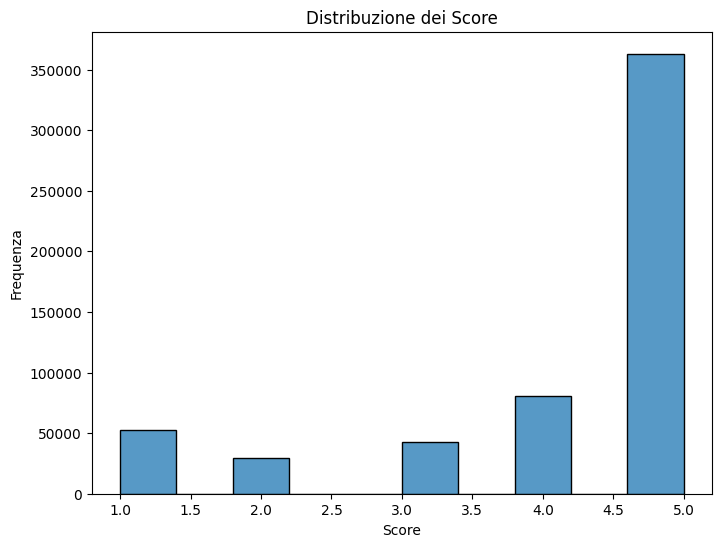

In [6]:
# Istogramma per la colonna 'rating'
plt.figure(figsize=(8, 6))
sns.histplot(reviews_a['Score'], bins=10)
plt.title('Distribuzione dei Score')
plt.xlabel('Score')
plt.ylabel('Frequenza')
plt.show()

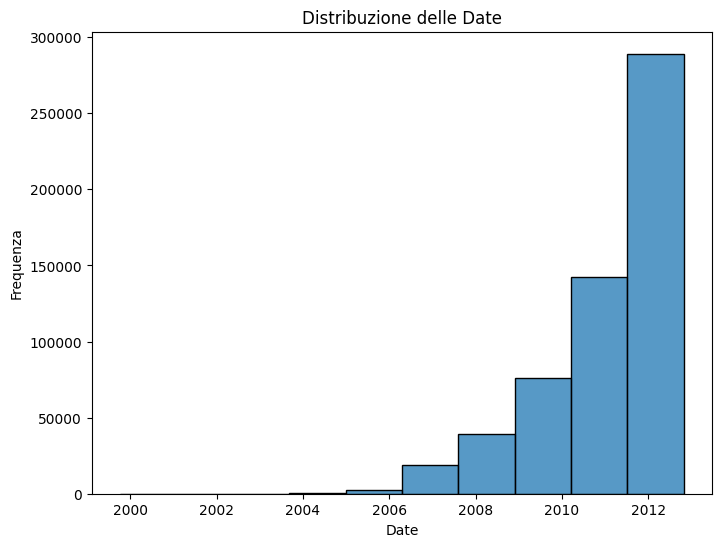

In [7]:
plt.figure(figsize=(8, 6))
sns.histplot(reviews_a['Time'], bins=10)  # kde=True aggiunge la stima della densità di kernel
plt.title('Distribuzione delle Date')
plt.xlabel('Date')
plt.ylabel('Frequenza')
plt.show()

In [8]:
# Informazioni generali sul dataset
print("\nInformazioni sul dataset:")
print(reviews_a.info())


Informazioni sul dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Id                      568454 non-null  int64         
 1   ProductId               568454 non-null  object        
 2   UserId                  568454 non-null  object        
 3   ProfileName             568428 non-null  object        
 4   HelpfulnessNumerator    568454 non-null  int64         
 5   HelpfulnessDenominator  568454 non-null  int64         
 6   Score                   568454 non-null  int64         
 7   Time                    568454 non-null  datetime64[ns]
 8   Summary                 568427 non-null  object        
 9   Text                    568454 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 43.4+ MB
None


In [9]:
# Dizionario di slang e acronimi (aggiungere altri se necessario)
slang_dict = {
    "u": "you", "ur": "your", "r": "are", "idk": "I don't know", "btw": "by the way",
    "imo": "in my opinion", "imho": "in my humble opinion", "lol": "laughing out loud",
    "lmao": "laughing my ass off", "brb": "be right back", "gtg": "got to go",
    "smh": "shaking my head", "omg": "oh my god", "thx": "thanks", "ty": "thank you",
    "pls": "please", "plz": "please", "gr8": "great", "b4": "before", "cuz": "because",
    "bc": "because", "wanna": "want to", "gonna": "going to", "gotta": "got to"
}
def clean_text(text):
    # Convertire in minuscolo
    text = text.lower()
    # Decodifica entità HTML (&quot; -> ", &amp; -> &, ecc.)
    text = html.unescape(text)
    # Rimuovere menzioni, URL e hashtag
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)  # Menzioni
    text = re.sub(r'https?://\S+', '', text)   # URL
    text = re.sub(r'#', '', text)               # Rimuove hashtag mantenendo la parola
    text = re.sub(r'www\.\S+', '', text)    # Rimuove URL che iniziano con www
    
    # Sostituzione di acronimi e slang
    words = text.split()
    words = [slang_dict[word] if word in slang_dict else word for word in words]
    text = ' '.join(words)
    
    # Rimozione di punteggiatura e numeri
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    # Tokenizzazione
    tokens = word_tokenize(text)
    
    # Rimozione stopwords
    stop_words = set(stopwords.words('english'))
    
    tokens = [word for word in tokens if word not in stop_words]

    # Rimozione della parola "walmart"
    words_to_remove = ["br", "walmart"]
    tokens = [word for word in tokens if word not in words_to_remove]
    
    # Stemming
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(word) for word in tokens]
    
    return ' '.join(tokens)

In [10]:
# Applicare la pulizia alla colonna "SentimentText"
reviews_a["Text"] = reviews_a["Text"].astype(str).apply(clean_text)
reviews_a["Text"].head

<bound method NDFrame.head of 0         bought sever vital can dog food product found ...
1         product arriv label jumbo salt peanut peanut a...
2         confect around centuri light pillowi citru gel...
3         look secret ingredi robitussin believ found go...
4         great taffi great price wide assort yummi taff...
                                ...                        
568449    great sesam chicken good better restur eaten h...
568450    disappoint flavor chocol note especi weak milk...
568451    star small give one train session tri train do...
568452    best treat train reward dog good groom lower c...
568453    satisfi product advertis use cereal raw vinega...
Name: Text, Length: 568454, dtype: object>

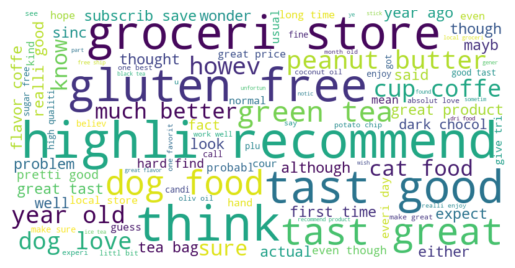

In [11]:
#nuvola di parole
text = " ".join(reviews_a['Text'])
wordcloud = WordCloud(width=800, height=400, max_words=100, background_color='white', colormap='viridis').generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

Parole più comuni nei testi positivi:
     Words  Counts
0     tast   49910
1     like   48422
2  product   40707
3      one   30631
4   flavor   30105
Parole più comuni nei testi neutrali:
    Words  Counts
0    like   30345
1    tast   28290
2  flavor   23863
3   coffe   19198
4    good   19091

Parole più comuni nei testi negativi:
    Words  Counts
0    like  209906
1    tast  187415
2  flavor  168077
3    love  165807
4    good  164011


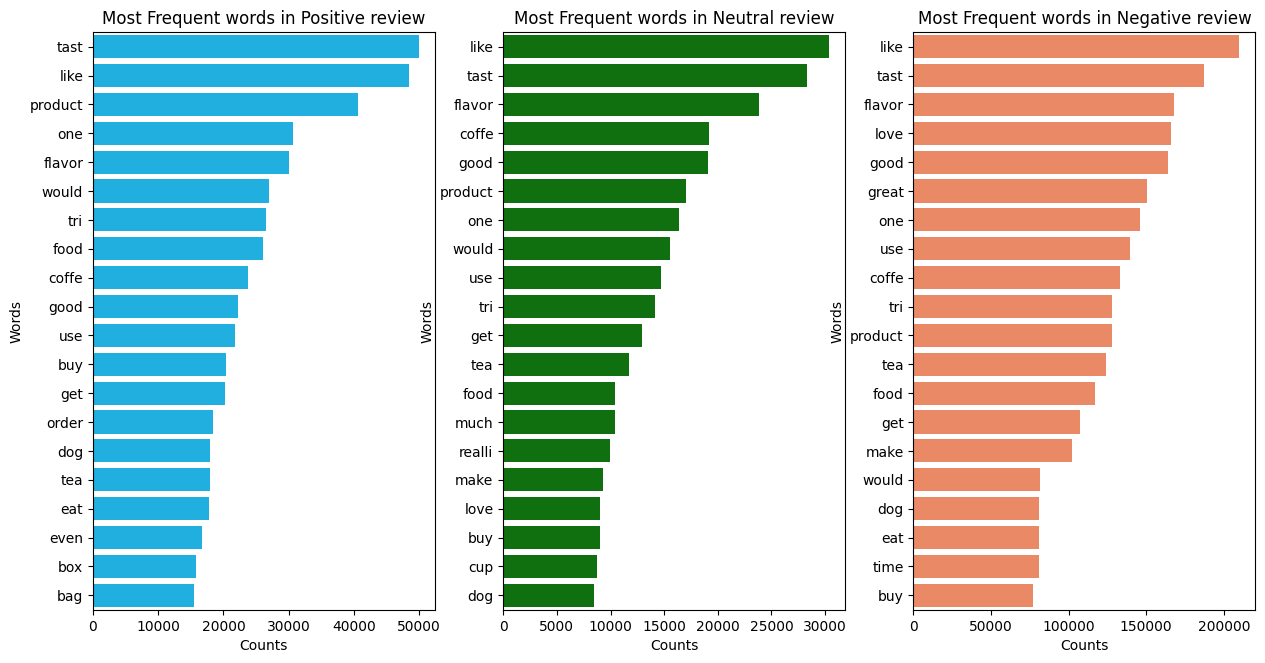

In [12]:
# Filtra i revies
positive_texts = " ".join(reviews_a[reviews_a['Score'] == 1]['Text'])+' '.join(reviews_a[reviews_a['Score'] == 2]['Text'])
neutral_texts= " ".join(reviews_a[reviews_a['Score'] == 3]['Text'])
negative_texts = " ".join(reviews_a[reviews_a['Score'] == 4]['Text'])+' '.join(reviews_a[reviews_a['Score'] == 5]['Text'])


# Conta le parole più comuni per i testi positivi
top_pos = Counter(positive_texts.split())
top_pos_df = pd.DataFrame(top_pos.most_common(100), columns=['Words', 'Counts'])

# Conta le parole più comuni per i testi positivi
top_neu = Counter(neutral_texts.split())
top_neu_df = pd.DataFrame(top_neu.most_common(100), columns=['Words', 'Counts'])


# Conta le parole più comuni per i testi negativi
top_neg = Counter(negative_texts.split())
top_neg_df = pd.DataFrame(top_neg.most_common(100), columns=['Words', 'Counts'])

# Stampa i risultati
print("Parole più comuni nei testi positivi:")
print(top_pos_df.head())

print("Parole più comuni nei testi neutrali:")
print(top_neu_df.head())

print("\nParole più comuni nei testi negativi:")
print(top_neg_df.head())

fig,ax=plt.subplots(nrows=1,ncols=3,figsize=(15,7.5))
sns.barplot(y='Words',x='Counts',data=top_pos_df[:20],color='deepskyblue',ax=ax[0])
sns.barplot(y='Words',x='Counts',data=top_neu_df[:20],color='green',ax=ax[1])
sns.barplot(y='Words',x='Counts',data=top_neg_df[:20],color='coral',ax=ax[2])
ax[0].set_title("Most Frequent words in Positive review")
ax[1].set_title("Most Frequent words in Neutral review")
ax[2].set_title("Most Frequent words in Negative review")
plt.show()



In [13]:
#criteri empirici
def analisi_ttr_hapax(testo):
    tokens = word_tokenize(testo)
    tipi = set(tokens)
    ttr = len(tipi) / len(tokens) *100

    freq_dist = FreqDist(tokens)
    hapax = [word for word, freq in freq_dist.items() if freq == 1]
    percentuale_hapax = (len(hapax) / len(tokens)) * 100 if tokens else 0

    return ttr, percentuale_hapax

In [14]:
# Concatena tutte le recensioni in un'unica stringa
corpus_a = " ".join(reviews_a["Text"].tolist())

# Applica la funzione analisi_ttr_hapax all'intero corpus
ttr, percentuale_hapax = analisi_ttr_hapax(corpus_a)

# Stampa i risultati
print("TTR:", ttr)
print("Percentuale di Hapax:", percentuale_hapax)

TTR: 0.33630398737214034
Percentuale di Hapax: 0.1371650207324499


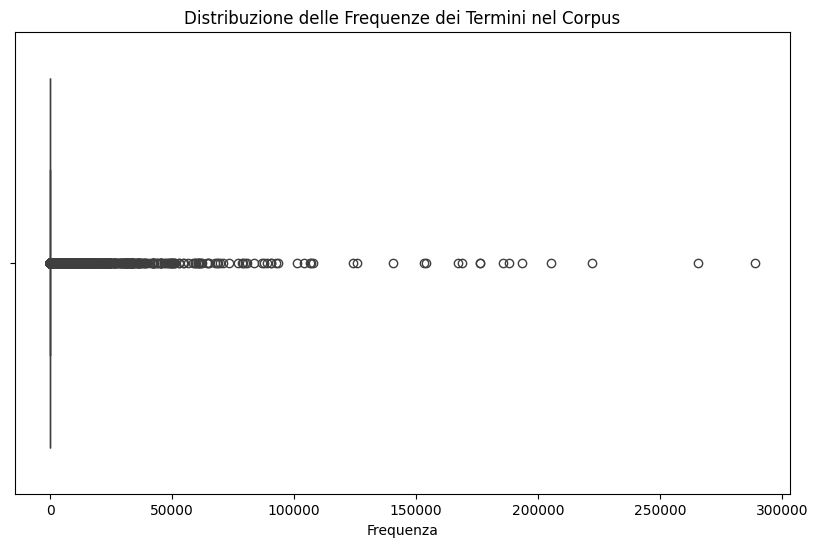

In [15]:
#TF
# Crea un oggetto CountVectorizer
vectorizer = CountVectorizer()

# Adatta il vectorizer al corpus e trasforma il corpus in una matrice TFM
tf_matrix_a = vectorizer.fit_transform([corpus_a]) 

# Ottieni i nomi delle feature (i termini)
feature_names = vectorizer.get_feature_names_out()

# Crea un DataFrame pandas dalla matrice TFM
tf_df_a = pd.DataFrame(tf_matrix_a.toarray(), columns=feature_names)

# Visualizzazione delle Frequenze dei Termini

# Calcola la somma delle frequenze per ogni termine
term_frequencies_a = tf_df_a.sum()

# a. Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=term_frequencies_a)
plt.title("Distribuzione delle Frequenze dei Termini nel Corpus")
plt.xlabel("Frequenza")
plt.show()

Conteggio campioni per classe originale:
 Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64

Numero minimo di campioni per classe: 29769


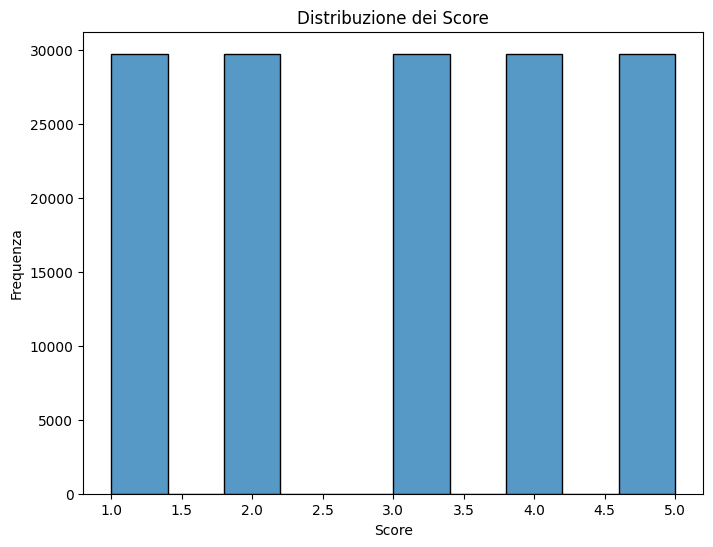

<bound method NDFrame.head of             Id   ProductId          UserId                   ProfileName  \
348178  348179  B000O160KE  A1P9NJ7JQZRHCT                   Professor X   
306507  306508  B004NB79VU   ACP87CNOMX1DJ  Tanya L. Ouzts "wedding mom"   
228312  228313  B003VXHGPK  A25UTJ1AXFC0Z9                Judy Armstrong   
448368  448369  B0030FGMFY  A2JER2JSWJG5VL                        Jaybee   
515440  515441  B004S04X4W   AY1EF0GOH80EK               Natasha Stryker   
...        ...         ...             ...                           ...   
563911  563912  B002C54UK2  A1A4XFEN2S2WLQ                       BBonvi2   
210094  210095  B000MM6R1C  A2EOXZBMI70VF7        Dungeon Mistress "Dee"   
549352  549353  B004728MI4  A216YA3CYXIOGI             lady in the south   
41916    41917  B006Q7YFLQ  A2WX8REGY23RQU          Elakshi "brighteyes"   
128342  128343  B002Q8PQAS  A1QIZ8LSPWNXZI              George M Watkins   

        HelpfulnessNumerator  HelpfulnessDenominator  Sco

In [16]:
# Bilanciamento delle classi
# Calcola il numero di campioni per ogni classe
class_counts = reviews_a['Score'].value_counts()
print("Conteggio campioni per classe originale:\n", class_counts)
# Identifica la classe con il minor numero di campioni
min_count = class_counts.min()
print("\nNumero minimo di campioni per classe:", min_count)

# Separa il DataFrame per la classe 5 e le altre classi
df_classe_5 = reviews_a[reviews_a['Score'] == 5]
df_classe_4 = reviews_a[reviews_a['Score'] == 4]
df_classe_3 = reviews_a[reviews_a['Score'] == 3]
df_classe_2 = reviews_a[reviews_a['Score'] == 2]
df_classe_1 = reviews_a[reviews_a['Score'] == 1]

# Sottocampiona casualmente le classi al numero di campioni della classe meno rappresentata
df_classe_5_undersampled = df_classe_5.sample(n=min_count, random_state=42) # random_state per la riproducibilità
df_classe_4_undersampled = df_classe_4.sample(n=min_count, random_state=42) # random_state per la riproducibilità
df_classe_3_undersampled = df_classe_3.sample(n=min_count, random_state=42) # random_state per la riproducibilità
df_classe_2_undersampled = df_classe_2.sample(n=min_count, random_state=42) # random_state per la riproducibilità
df_classe_1_undersampled = df_classe_1.sample(n=min_count, random_state=42) # random_state per la riproducibilità

# Combina il DataFrame sottocampionato della classe 5 con le altre classi
reviews_a_balanced = pd.concat([df_classe_1_undersampled, df_classe_2_undersampled, df_classe_3_undersampled, df_classe_4_undersampled, df_classe_5_undersampled])

# Istogramma per la colonna 'Score'
plt.figure(figsize=(8, 6))
sns.histplot(reviews_a_balanced['Score'], bins=10)
plt.title('Distribuzione dei Score')
plt.xlabel('Score')
plt.ylabel('Frequenza')
plt.show()

reviews_a_balanced.head

In [17]:
#TF-IDF
# Crea un oggetto TfidfVectorizer
vectorizer_tfidf_a = TfidfVectorizer(max_df=1.0, min_df=1, stop_words='english')

# Adatta il vectorizer al corpus e trasforma il corpus in una matrice TDM
tfidf_matrix = vectorizer_tfidf_a.fit_transform(reviews_a_balanced["Text"])

In [21]:
#Doc2Vec
tagged_data = []
for index, row in reviews_a_balanced.iterrows():
    tokens = word_tokenize(row['Text'].lower()) # Tokenizzazione e conversione in minuscolo
    tagged_data.append(TaggedDocument(words=tokens, tags=[str(index)])) # Usa l'indice come etichetta
model_dv = Doc2Vec(tagged_data, vector_size=100, window=5, min_count=1, epochs=50)

# Parametri importanti:
# - vector_size: la dimensionalità del vettore del documento
# - window: la dimensione della finestra di contesto
# - min_count: ignora tutte le parole con frequenza totale inferiore a questo valore
# - epochs: il numero di passaggi sull'intero corpus di addestramento

In [29]:
print(model_dv.dv.index_to_key[:10])

['348178', '306507', '228312', '448368', '515440', '441414', '38736', '343226', '295696', '366274']


In [32]:
# Per ottenere i vettori di tutti i documenti
doc_vectors = [model_dv.dv[str(idx)] for idx in reviews_a_balanced.index]
# Visualizza i primi vettori (ad esempio, i primi 5)
print(doc_vectors[:3])

[array([ 0.07378643, -0.84818935, -0.95556974,  2.0947623 ,  0.27605498,
        0.01205231, -0.6128378 ,  0.20243554, -0.8659916 , -1.2497432 ,
        0.3752229 ,  0.4385827 ,  1.6416442 , -0.62164736,  0.15418573,
       -1.6561007 ,  1.4206204 , -0.62889296,  1.2022512 , -0.4998219 ,
       -0.31034005,  0.407093  ,  0.7615095 , -0.00676007,  0.47771937,
       -0.23278747, -1.4537688 , -0.40090758, -1.5873209 ,  0.29789552,
        1.1230954 ,  0.67051905,  0.04800431,  0.6269699 , -0.7006673 ,
       -1.2904305 ,  0.29450986, -1.6713076 , -1.0406183 , -0.7076887 ,
        0.19473264, -0.03997825, -0.69742006, -0.41590482, -1.0359802 ,
        0.70951235, -0.34939957, -1.1871252 ,  0.26022556, -0.9117482 ,
       -0.6676405 ,  0.9166138 ,  0.78274006, -1.1285077 ,  1.0625628 ,
       -0.9184083 ,  0.60527474,  0.05194357,  0.12440212,  0.21835989,
        1.1244528 ,  0.24401078, -0.86389977, -0.20379038,  0.14236283,
        1.57041   , -0.00970332,  0.5970999 , -0.85267156, -0.3

In [ ]:
#LSA manca da inserire _balanced per dataset bilanciato
# Numero di componenti desiderate (argomenti latenti)
n_components = 4  # Puoi regolare questo valore

# Crea un oggetto TruncatedSVD
lsa_a = TruncatedSVD(n_components=n_components)

# Applica LSA alla matrice TF-IDF
lsa_matrix_a = lsa_a.fit_transform(tfidf_matrix)

# Ottieni i termini (feature names)
terms_a = vectorizer_tfidf_a.get_feature_names_out()

# Stampa i termini più importanti per ogni argomento latente
#for i, component in enumerate(lsa_a.components_):
#    terms_zipped = zip(terms_a, component)
#    top_terms = sorted(terms_zipped, key=lambda x: x[1], reverse=True)[:10]  # Ottieni i primi 10 termini
#    print(f"Argomento {i + 1}:")
#    for term, score in top_terms:
#        print(f"  {term}: {score:.4f}")

# Visualizzazione delle Parole per Topic con Grafico a Dispersione (Termini Limitati)
num_terms_to_display = 20  # Puoi regolare questo valore

for i, component in enumerate(lsa_a.components_):
    terms_zipped = zip(terms_a, component)
    top_terms = sorted(terms_zipped, key=lambda x: x[1], reverse=True)[:num_terms_to_display]
    terms, scores = zip(*top_terms)

    plt.figure(figsize=(10, 6))
    plt.scatter(scores, range(len(terms)))
    for j, term in enumerate(terms):
        plt.annotate(term, (scores[j], j))

    plt.title(f"Argomento {i + 1} - Grafico a Dispersione")
    plt.xlabel("Punteggio")
    plt.ylabel("Termini")
    plt.yticks([])  # Rimuovi i tick sull'asse y
    plt.show()

In [ ]:
#LDA
# Crea un oggetto CountVectorizer
vectorizer_lda_a = CountVectorizer(max_df=1.0, min_df=1, stop_words='english')

# Adatta il vectorizer al corpus e trasforma il corpus in una matrice DTM
dtm_a = vectorizer_lda_a.fit_transform(reviews_a_balanced["Text"])

# Numero di argomenti desiderati
n_topics = 3  # Puoi regolare questo valore

# Modifica i parametri alpha e beta
alpha = 0.1  # Puoi regolare questo valore
beta = 0.1  # Puoi regolare questo valore

# Crea un oggetto LatentDirichletAllocation con i parametri modificati
lda_a = LatentDirichletAllocation(n_components=n_topics, random_state=42, doc_topic_prior=alpha, topic_word_prior=beta)

# Applica LDA alla matrice DTM
lda_a.fit(dtm_a)

# Ottieni i termini (feature names)
terms_lda_a = vectorizer_lda_a.get_feature_names_out()

# Stampa i termini più importanti per ogni argomento
for i, topic in enumerate(lda_a.components_):
    terms_zipped = zip(terms_lda_a, topic)
    top_terms = sorted(terms_zipped, key=lambda x: x[1], reverse=True)[:10]  # Ottieni i primi 10 termini
    print(f"Argomento {i + 1}:")
    for term, score in top_terms:
        print(f"  {term}: {score:.4f}")
    
    # Visualizzazione con Grafico a Barre
    terms, scores = zip(*top_terms)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=list(scores), y=list(terms))
    plt.title(f"Argomento {i + 1}")
    plt.xlabel("Punteggio")
    plt.ylabel("Termini")
    plt.show()

In [ ]:
#Apprendimento sui specifici Topic
# 1. Identificazione dei Topic e Assegnazione delle Recensioni
topic_probabilities = lda_a.transform(dtm_a)
reviews_a_balanced['topic'] = topic_probabilities.argmax(axis=1)

# 2. Creazione del Dataset Etichettato
data_lda_a = reviews_a_balanced[['Text', 'topic', 'Score']]

# 3. Preparazione dei Dati per la Classificazione
X_train, X_test, y_train, y_test = train_test_split(
    data_lda_a[['Text', 'topic']], data_lda_a['Score'], test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer()
X_train_text = vectorizer.fit_transform(X_train['Text'])
X_test_text = vectorizer.transform(X_test['Text'])

X_train_topic = pd.get_dummies(X_train['topic'], prefix='topic').values
X_test_topic = pd.get_dummies(X_test['topic'], prefix='topic').values
# Questa riga di codice converte la colonna 'topic' in un array di variabili dummy 
# Combina le caratteristiche manualmente
X_train_combined = sp.hstack((X_train_text, X_train_topic))
X_test_combined = sp.hstack((X_test_text, X_test_topic))
#Questa funzione di scipy.sparse è progettata per concatenare matrici sparse e array densi in modo efficiente.

In [ ]:
print (X_train_text)
print (X_train_topic)
print (X_train_combined)
print (X_train)
print(y_train)

In [ ]:
#Logistic Regression
def model_logistic_regression(X_train, X_test, y_train, y_test):
    # 1. Creazione e addestramento del modello
    model_lg = LogisticRegression(max_iter=500, random_state=42)
    model_lg.fit(X_train, y_train)

    # 2. Previsioni sul test set
    y_pred_test = model_lg.predict(X_test)
    y_pred_train = model_lg.predict(X_train)
    
# 3. Calcola le metriche di valutazione per la classificazione
    accuracy_train = accuracy_score(y_train, y_pred_train)
    precision_train = precision_score(y_train, y_pred_train, average='weighted')
    recall_train = recall_score(y_train, y_pred_train, average='weighted')
    f1_train = f1_score(y_train, y_pred_train, average='weighted')

    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test, average='weighted')
    recall_test = recall_score(y_test, y_pred_test, average='weighted')
    f1_test = f1_score(y_test, y_pred_test, average='weighted')

    # 4. Stampa le metriche di valutazione
    print("Valutazione train")
    print(f"Accuracy: {accuracy_train}, Precision: {precision_train}, Recall: {recall_train}, F1-score: {f1_train}")
    print("Valutazione test")
    print(f"Accuracy: {accuracy_test}, Precision: {precision_test}, Recall: {recall_test}, F1-score: {f1_test}")

    return model_lg

In [ ]:
modello_log_reg= model_logistic_regression(X_train_combined,X_test_combined, y_train, y_test)

In [ ]:
#Gradient Boosting
def model_gradient_boosting(X_train, X_test, y_train, y_test):
     # 1. Creazione e addestramento del modello
    model_gb = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.5, subsample=0.75)
    model_gb.fit(X_train, y_train)

    # 2. Previsioni sul test set
    y_pred_test = model_gb.predict(X_test)
    y_pred_train = model_gb.predict(X_train)

    # 3. Calcola le metriche di valutazione per la classificazione
    accuracy_train = accuracy_score(y_train, y_pred_train)
    precision_train = precision_score(y_train, y_pred_train, average='weighted')
    recall_train = recall_score(y_train, y_pred_train, average='weighted')
    f1_train = f1_score(y_train, y_pred_train, average='weighted')

    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test, average='weighted')
    recall_test = recall_score(y_test, y_pred_test, average='weighted')
    f1_test = f1_score(y_test, y_pred_test, average='weighted')

    # 4. Stampa le metriche di valutazione
    print("Valutazione train")
    print(f"Accuracy: {accuracy_train}, Precision: {precision_train}, Recall: {recall_train}, F1-score: {f1_train}")
    print("Valutazione test")
    print(f"Accuracy: {accuracy_test}, Precision: {precision_test}, Recall: {recall_test}, F1-score: {f1_test}")

    return model_gb

In [ ]:
modello_gb= model_gradient_boosting(X_train_combined,X_test_combined, y_train, y_test)

In [ ]:
#rete neurale 